In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
PROJECT_PATH = '/content/drive/MyDrive/WasteClassificationProject'

if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)
    print(f"Created folder at {PROJECT_PATH}")
else:
    print(f"Folder already exists at {PROJECT_PATH}")

Folder already exists at /content/drive/MyDrive/WasteClassificationProject


In [3]:
!cp kaggle.json /content/drive/MyDrive/WasteClassificationProject/
print("File successfully saved to Drive!")

cp: cannot stat 'kaggle.json': No such file or directory
File successfully saved to Drive!


In [4]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/WasteClassificationProject/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle is now linked to your Google Drive!")

Kaggle is now linked to your Google Drive!


In [5]:
!kaggle datasets download -d mostafaabla/garbage-classification
!unzip -o -q garbage-classification.zip -d dataset

print("Dataset is ready to go!")

Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
garbage-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset is ready to go!


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = 'dataset/garbage_classification'

# Setup Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2 # 20% for testing during training
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 12415 images belonging to 12 classes.
Found 3100 images belonging to 12 classes.


In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

# Load the brain (pre-trained weights)
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras import callbacks

# Stop training if the model stops getting better
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Starting training...")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Starting training...
Epoch 1/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 272s 649ms/step - accuracy: 0.8309 - loss: 0.5434 - val_accuracy: 0.8403 - val_loss: 0.4934
Epoch 2/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 224s 577ms/step - accuracy: 0.8888 - loss: 0.3458 - val_accuracy: 0.8768 - val_loss: 0.3705
Epoch 3/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 222s 572ms/step - accuracy: 0.9034 - loss: 0.3060 - val_accuracy: 0.8774 - val_loss: 0.3656
Epoch 4/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 219s 564ms/step - accuracy: 0.9044 - loss: 0.2895 - val_accuracy: 0.8732 - val_loss: 0.3812
Epoch 5/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 221s 570ms/step - accuracy: 0.9103 - loss: 0.2611 - val_accuracy: 0.8826 - val_loss: 0.3427
Epoch 6/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 221s 569ms/step - accuracy: 0.9182 - loss: 0.2479 - val_accuracy: 0.8881 - val_loss: 0.3222
Epoch 7/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 219s 565ms/step - accuracy: 0.9246 - loss: 0.2264 - val_accuracy: 0.8768 - val_loss: 0.3800
Epoch 8/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 221s 570ms/step

In [8]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/WasteClassificationProject/waste_model_v1.h5')
print("Model loaded successfully! You are ready to predict.")

Model loaded successfully! You are ready to predict.


Saving plasticbottle1.jpg to plasticbottle1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


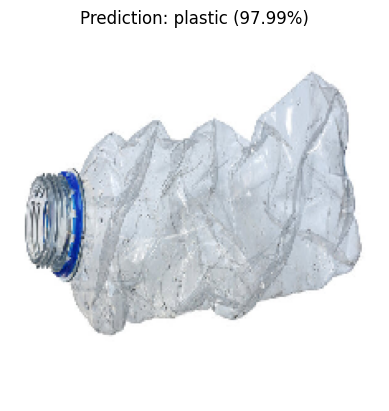

In [9]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for fn in uploaded.keys():
  # Load and predict
  img = image.load_img(fn, target_size=(224, 224))
  img_array = image.img_to_array(img) / 255.0
  img_array = np.expand_dims(img_array, axis=0)

  res = model.predict(img_array)
  class_idx = np.argmax(res)
  labels = list(train_generator.class_indices.keys())

  # Show result
  plt.imshow(img)
  plt.title(f"Prediction: {labels[class_idx]} ({100*np.max(res):.2f}%)")
  plt.axis('off')
  plt.show()

In [10]:
model.save('/content/drive/MyDrive/WasteClassificationProject/waste_model_v1.h5')
print("Model is now safely stored in Google Drive")

Model is now safely stored in Google Drive


In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image
import os

# Updated CSS for better compatibility
custom_css = """
#container { max-width: 900px; margin: auto; padding-top: 20px; }
.header { text-align: center; margin-bottom: 30px; }
.main-box { border-radius: 15px; border: 1px solid #e0e0e0; padding: 20px; background: white; }
.predict-btn { background-color: #10b981 !important; color: white !important; }
.result-display { font-size: 24px; font-weight: bold; color: #065f46; background: #f0fdf4; padding: 15px; border-radius: 10px; text-align: center; margin-bottom: 10px; }
"""

# The prediction logic stays the same
def predict_ui(img):
    if img is None: return "Waiting...", {}
    img_resized = img.resize((224, 224))
    img_array = image.img_to_array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array)[0]
    top_3_idx = np.argsort(prediction)[-3:][::-1]
    top_3_results = {labels[i]: float(prediction[i]) for i in top_3_idx}
    best_class = labels[top_3_idx[0]].upper().replace('-', ' ')
    conf = prediction[top_3_idx[0]] * 100
    result_html = f"<div class='result-display'>{best_class} <br> <span style='font-size:16px; color:#6b7280;'>Confidence: {conf:.1f}%</span></div>"
    return result_html, top_3_results

# NEW LAYOUT (Fixed gr.Div error)
with gr.Blocks(css=custom_css, theme="soft") as demo:
    with gr.Column(elem_id="container"):
        # Header Section
        gr.HTML("""
            <div class='header'>
                <h1 style='font-size: 32px; color: #111827;'>♻️ Waste AI Classifier Pro</h1>
                <p style='color: #6b7280;'>Intelligent Recycling Assistant | High-Accuracy Machine Vision</p>
            </div>
        """)

        with gr.Row(elem_classes="main-box"):
            # Left Column
            with gr.Column():
                input_img = gr.Image(type="pil", label="INPUT ZONE")
                with gr.Row():
                    clear_btn = gr.Button("🗑️ Clear")
                    submit_btn = gr.Button("✨ Analyze", variant="primary", elem_classes="predict-btn")

            # Right Column
            with gr.Column():
                gr.Markdown("### PREDICTION RESULTS")
                output_html = gr.HTML("<div style='color:#9ca3af; text-align:center;'>Ready for analysis...</div>")
                output_label = gr.Label(label="Detailed Probability Breakdown", num_top_classes=3)

        # Examples
        gr.Examples(
            examples=[os.path.join(DATA_DIR, 'plastic/plastic1.jpg'),
                      os.path.join(DATA_DIR, 'metal/metal1.jpg')],
            inputs=input_img
        )

    # Logic
    submit_btn.click(fn=predict_ui, inputs=input_img, outputs=[output_html, output_label])
    clear_btn.click(lambda: (None, "<div style='color:#9ca3af; text-align:center;'>Ready...</div>", {}),
                    None, [input_img, output_html, output_label])

# Launch!
demo.launch(share=True, debug=True)

/tmp/ipykernel_8789/3081434630.py:30: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme="soft") as demo:
/tmp/ipykernel_8789/3081434630.py:30: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme="soft") as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://fc072dd93a1a0b7d36.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
